# Career Intelligence & Skills Evolution Analyzer
### 02_nlp_and_modeling.ipynb

#### Objective
This notebook builds predictive models for:
- Salary prediction
- Automation risk classification
- Skill importance analysis
- Explainable model comparison

#### Inputs
- `jobs_master.csv`
- `student_profiles.csv`

#### Outputs
- Trained models
- Evaluation metrics
- Feature importance plots
- Prediction-ready artifacts

IMPORTS & LOAD CLEANED DATA

In [3]:
import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
DATA_DIR = Path("output")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [4]:
try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

#### 1. Load Cleaned Data
Use the outputs created in `01_eda_and_preprocessing.ipynb`.

In [5]:
jobs = pd.read_csv(DATA_DIR / "jobs_master.csv")
students = pd.read_csv(DATA_DIR / "student_profiles.csv")

print(jobs.shape)
print(students.shape)
display(jobs.head())
display(students.head())

(5466, 11)
(3600, 22)


,job_title,industry,location,posting_month,job_description,job_description_clean,skills,num_skills,automation_risk_score,automation_risk_label,median_salary_usd
0,data,oowlish technology,remote,2024-10,Oowlish Technology - Founding Engineer - AI/Py...,oowlish technology - founding engineer - ai/py...,"['aws', 'communication', 'git', 'python']",4,44,medium,60000.0
1,other,oneida esc group,remote,2024-10,Oneida Total Integrated Enterprises (OTIE) cur...,oneida total integrated enterprises otie curre...,"['aws', 'excel']",2,52,medium,60000.0
2,management,affinity psychological services. p.c.,remote,2024-10,Affinity Psychological Services is a rapidly-g...,affinity psychological services is a rapidly-g...,"['communication', 'leadership']",2,67,high,60000.0
3,other,the christian and missionary alliance - u.s. c...,remote,2024-10,Job Overview for Director of Children’s Minist...,job overview for director of children s minist...,[],0,55,medium,60000.0
4,data,cdc foundation,full-time,2024-10,CDC Foundation - Data Engineer Data Engineer O...,cdc foundation - data engineer data engineer o...,"['aws', 'azure', 'python', 'r', 'sql']",5,63,medium,60000.0


,course,job_profession,student,linguistic,musical,bodily,logical_mathematical,spatial_visualization,interpersonal,intrapersonal,...,p1,p2,p3,p4,p5,p6,p7,p8,student_id,target_profession
0,NaN,Astronomer\n,S1,11,5,12,16,17,11,18,...,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_0,astronomer
1,NaN,Astronomer\n,S2,12,6,12,16,16,11,18,...,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_1,astronomer
2,NaN,Astronomer\n,S3,13,7,12,16,15,11,18,...,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_2,astronomer
3,NaN,Astronomer\n,S4,14,8,12,16,19,11,18,...,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_3,astronomer
4,NaN,Astronomer\n,S5,13,9,12,16,20,11,19,...,AVG,POOR,AVG,BEST,BEST,AVG,BEST,BEST,student_4,astronomer


#### 2. Validate Columns
Check that the expected target and feature columns exist.

In [6]:
print(jobs.columns.tolist())

required_cols = [
    "job_title", "industry", "location", "job_description_clean",
    "skills", "num_skills", "automation_risk_score",
    "automation_risk_label", "median_salary_usd"
]

missing = [c for c in required_cols if c not in jobs.columns]
print("Missing columns:", missing)

['job_title', 'industry', 'location', 'posting_month', 'job_description', 'job_description_clean', 'skills', 'num_skills', 'automation_risk_score', 'automation_risk_label', 'median_salary_usd']
Missing columns: []


#### 3. Prepare Targets
Set up salary regression and automation-risk classification targets.

In [7]:
jobs = jobs.copy()

jobs["median_salary_usd"] = pd.to_numeric(jobs["median_salary_usd"], errors="coerce")
jobs["automation_risk_label"] = jobs["automation_risk_label"].astype(str).str.lower().str.strip()

jobs = jobs.dropna(subset=["median_salary_usd", "automation_risk_label"])
jobs = jobs[jobs["median_salary_usd"] > 0]

print(jobs.shape)
print(jobs["automation_risk_label"].value_counts())

(5466, 11)
automation_risk_label
medium    4402
high       728
low        336
Name: count, dtype: int64


#### 4. Salary Prediction Features
Create model inputs from structured data and skills.

In [8]:
jobs["skills"] = jobs["skills"].apply(lambda x: eval(x) if isinstance(x, str) and x.startswith("[") else x)
jobs["skills"] = jobs["skills"].apply(lambda x: x if isinstance(x, list) else [])
jobs["skill_text"] = jobs["skills"].apply(lambda x: " ".join(x))

salary_features = jobs[[
    "job_title", "industry", "location", "job_description_clean",
    "num_skills", "skill_text"
]].copy()

salary_target = jobs["median_salary_usd"].copy()

#### 5. Salary Model Pipeline
Compare baseline and ensemble regressors.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    salary_features, salary_target, test_size=0.2, random_state=RANDOM_STATE
)

salary_preprocess = ColumnTransformer(
    transformers=[
        ("title", OneHotEncoder(handle_unknown="ignore"), ["job_title", "industry", "location"]),
        ("text", TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), "job_description_clean"),
        ("skill_text", TfidfVectorizer(max_features=2000, ngram_range=(1, 2)), "skill_text"),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), ["num_skills"])
    ],
    remainder="drop"
)

In [10]:
salary_models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

if XGBOOST_AVAILABLE:
    salary_models["XGBoost"] = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    )

In [11]:
salary_results = []

for name, model in salary_models.items():
    pipe = Pipeline([
        ("preprocess", salary_preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    salary_results.append([name, rmse, mae, r2])

salary_results_df = pd.DataFrame(salary_results, columns=["model", "rmse", "mae", "r2"])
display(salary_results_df.sort_values("rmse"))

,model,rmse,mae,r2
0,Ridge,0.0,0.0,1.0
1,RandomForest,0.0,0.0,1.0
2,XGBoost,0.0,0.0,1.0


#### 6. Select Best Salary Model
Pick the lowest-RMSE model for deployment.

In [12]:
best_salary_name = salary_results_df.sort_values("rmse").iloc[0]["model"]
best_salary_model = salary_models[best_salary_name]

salary_pipeline = Pipeline([
    ("preprocess", salary_preprocess),
    ("model", best_salary_model)
])

salary_pipeline.fit(X_train, y_train)
salary_preds = salary_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, salary_preds))

print("Best Salary Model:", best_salary_name)
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(y_test, salary_preds))
print("R2:", r2_score(y_test, salary_preds))

Best Salary Model: Ridge
RMSE: 0.0
MAE: 0.0
R2: 1.0


#### 7. Salary Prediction Diagnostics
Check predicted vs actual salary.

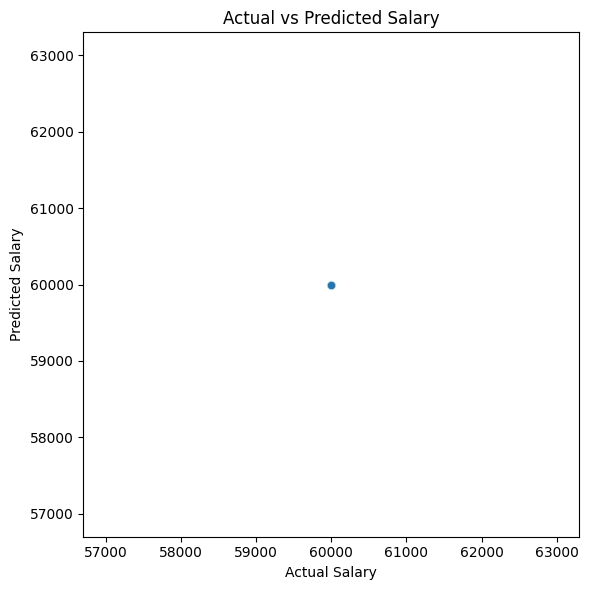

In [13]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=salary_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.tight_layout()
plt.show()

#### 8. Automation Risk Classification
Predict low / medium / high automation risk from text and skills.

In [14]:
risk_features = jobs[[
    "job_title", "industry", "location", "job_description_clean",
    "num_skills", "skill_text"
]].copy()

risk_target = jobs["automation_risk_label"].copy()

le_risk = LabelEncoder()
risk_target_encoded = le_risk.fit_transform(risk_target)
print(list(le_risk.classes_))

['high', 'low', 'medium']


In [15]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    risk_features, risk_target_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=risk_target_encoded
)

risk_preprocess = ColumnTransformer(
    transformers=[
        ("title", OneHotEncoder(handle_unknown="ignore"), ["job_title", "industry", "location"]),
        ("text", TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), "job_description_clean"),
        ("skill_text", TfidfVectorizer(max_features=2000, ngram_range=(1, 2)), "skill_text"),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), ["num_skills"])
    ],
    remainder="drop"
)

In [16]:
risk_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
    )
}

if XGBOOST_AVAILABLE:
    risk_models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss"
    )

In [17]:
risk_results = []

for name, model in risk_models.items():
    pipe = Pipeline([
        ("preprocess", risk_preprocess),
        ("model", model)
    ])
    pipe.fit(X_train_r, y_train_r)
    preds = pipe.predict(X_test_r)
    f1 = f1_score(y_test_r, preds, average="macro")
    precision = precision_score(y_test_r, preds, average="macro", zero_division=0)
    recall = recall_score(y_test_r, preds, average="macro", zero_division=0)
    risk_results.append([name, precision, recall, f1])

risk_results_df = pd.DataFrame(risk_results, columns=["model", "precision", "recall", "f1_macro"])
display(risk_results_df.sort_values("f1_macro", ascending=False))

,model,precision,recall,f1_macro
2,XGBoost,0.824771,0.677650,0.728520
0,LogisticRegression,0.577481,0.668852,0.610954
1,RandomForest,0.868487,0.419914,0.453729


#### 9. Select Best Risk Model
Use the model with the highest macro F1.

In [18]:
best_risk_name = risk_results_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]
best_risk_model = risk_models[best_risk_name]

risk_pipeline = Pipeline([
    ("preprocess", risk_preprocess),
    ("model", best_risk_model)
])

risk_pipeline.fit(X_train_r, y_train_r)
risk_preds = risk_pipeline.predict(X_test_r)

print("Best Risk Model:", best_risk_name)
print(classification_report(y_test_r, risk_preds, target_names=le_risk.classes_))

Best Risk Model: XGBoost
              precision    recall  f1-score   support

        high       0.87      0.72      0.79       146
         low       0.70      0.34      0.46        67
      medium       0.91      0.97      0.94       881

    accuracy                           0.90      1094
   macro avg       0.82      0.68      0.73      1094
weighted avg       0.89      0.90      0.89      1094



Confusion matrix

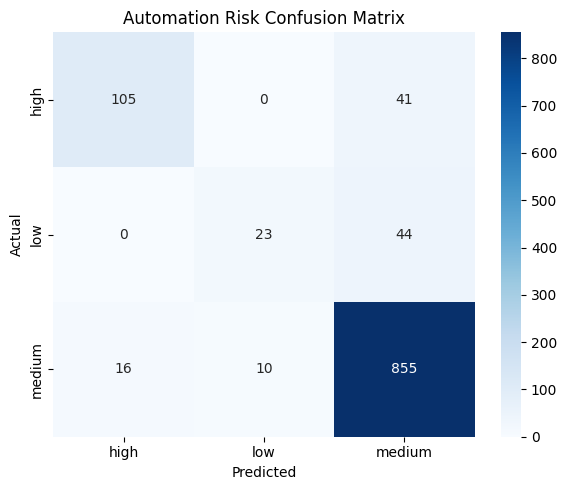

In [19]:
cm = confusion_matrix(y_test_r, risk_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_risk.classes_, yticklabels=le_risk.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Automation Risk Confusion Matrix")
plt.tight_layout()
plt.show()

#### 10. Interpretability
Extract important features for salary and risk prediction.

In [20]:
# For tree-based models, feature importance can be shown after preprocessing.
# For a clean project, start with permutation importance or SHAP later.
print("Salary model type:", best_salary_name)
print("Risk model type:", best_risk_name)

Salary model type: Ridge
Risk model type: XGBoost


Skill importance proxy

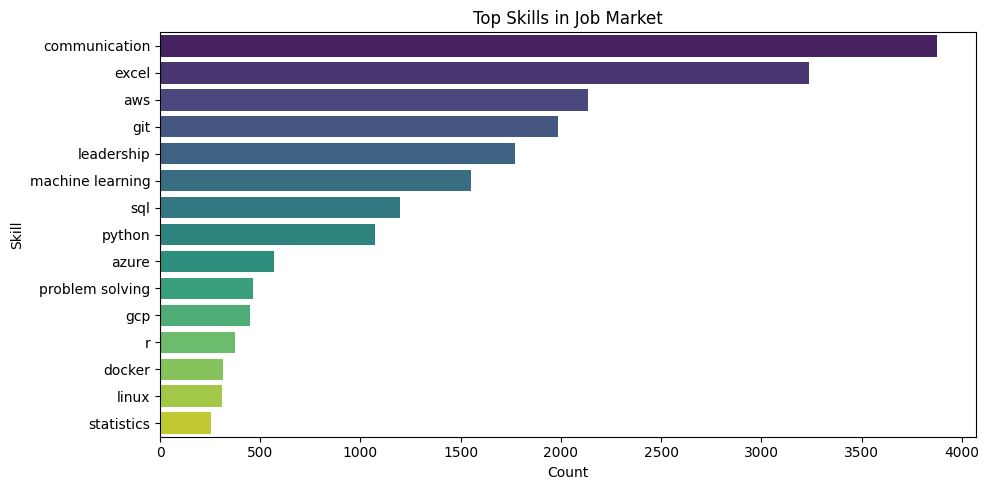

In [21]:
all_skills = [s for row in jobs["skills"] for s in row]
skill_counts = pd.Series(Counter(all_skills)).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=skill_counts.head(15).values, y=skill_counts.head(15).index, palette="viridis")
plt.title("Top Skills in Job Market")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

#### 11. Save Artifacts
Persist trained models and encoders for the dashboard and recommender.

In [22]:
joblib.dump(salary_pipeline, MODEL_DIR / "salary_pipeline.pkl")
joblib.dump(risk_pipeline, MODEL_DIR / "risk_pipeline.pkl")
joblib.dump(le_risk, MODEL_DIR / "risk_label_encoder.pkl")

with open(MODEL_DIR / "model_metrics.json", "w") as f:
    json.dump({
        "best_salary_model": best_salary_name,
        "best_risk_model": best_risk_name,
        "salary_metrics": salary_results_df.to_dict(orient="records"),
        "risk_metrics": risk_results_df.to_dict(orient="records")
    }, f, indent=2)

print("Saved all models and metrics.")

Saved all models and metrics.


#### 12. Prediction Helper
Create a reusable function for dashboard predictions.

In [23]:
def predict_salary_and_risk(job_title, industry, location, description, skills_list):
    skills_list = skills_list if isinstance(skills_list, list) else []
    temp = pd.DataFrame([{
        "job_title": str(job_title).lower(),
        "industry": str(industry).lower(),
        "location": str(location).lower(),
        "job_description_clean": str(description).lower(),
        "num_skills": len(skills_list),
        "skill_text": " ".join(skills_list)
    }])
    
    salary_pred = salary_pipeline.predict(temp)[0]
    risk_pred_idx = risk_pipeline.predict(temp)[0]
    risk_pred = le_risk.inverse_transform([risk_pred_idx])[0]
    
    return salary_pred, risk_pred

In [24]:
sample_salary, sample_risk = predict_salary_and_risk(
    "data analyst",
    "unknown",
    "canada",
    "responsible for data cleaning dashboard reporting and sql analysis",
    ["python", "sql", "excel", "power bi"]
)

print("Predicted salary:", sample_salary)
print("Predicted risk:", sample_risk)

Predicted salary: 60000.0
Predicted risk: medium


#### 13. Summary
This notebook produced:
- a salary regression model
- an automation-risk classifier
- evaluation metrics
- saved pipelines
- prediction helper functions

These artifacts will be used in:
- `03_career_recommendation_engine.ipynb`
- the dashboard app